## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Step 2: Load the Dataset

In [2]:
df = pd.read_csv("sales_data.csv")

In [3]:
print(f"Dataset has {df.shape[0]} rows and {df.shape[1]} columns")

Dataset has 1000 rows and 14 columns


## Step 3: Basic Data Exploration

First, I look at the data to understand its structure.

In [4]:
df.head()

,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep
0,1052,2023-02-03,Bob,North,5053.97,18,Furniture,152.75,267.22,Returning,0.09,Cash,Online,North-Bob
1,1093,2023-04-21,Bob,West,4384.02,17,Furniture,3816.39,4209.44,Returning,0.11,Cash,Retail,West-Bob
2,1015,2023-09-21,David,South,4631.23,30,Food,261.56,371.40,Returning,0.20,Bank Transfer,Retail,South-David
3,1072,2023-08-24,Bob,South,2167.94,39,Clothing,4330.03,4467.75,New,0.02,Credit Card,Retail,South-Bob
4,1061,2023-03-24,Charlie,East,3750.20,13,Electronics,637.37,692.71,New,0.08,Credit Card,Online,East-Charlie


In [5]:
df.tail()

,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep
995,1010,2023-04-15,Charlie,North,4733.88,4,Food,4943.03,5442.15,Returning,0.29,Cash,Online,North-Charlie
996,1067,2023-09-07,Bob,North,4716.36,37,Clothing,1754.32,1856.40,New,0.21,Bank Transfer,Retail,North-Bob
997,1018,2023-04-27,David,South,7629.70,17,Clothing,355.72,438.27,Returning,0.06,Bank Transfer,Online,South-David
998,1100,2023-12-20,David,West,1629.47,39,Electronics,3685.03,3743.39,New,0.01,Bank Transfer,Online,West-David
999,1086,2023-08-16,Alice,East,4923.93,48,Food,2632.58,2926.68,Returning,0.14,Cash,Online,East-Alice


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Product_ID            1000 non-null   int64  
 1   Sale_Date             1000 non-null   object 
 2   Sales_Rep             1000 non-null   object 
 3   Region                1000 non-null   object 
 4   Sales_Amount          1000 non-null   float64
 5   Quantity_Sold         1000 non-null   int64  
 6   Product_Category      1000 non-null   object 
 7   Unit_Cost             1000 non-null   float64
 8   Unit_Price            1000 non-null   float64
 9   Customer_Type         1000 non-null   object 
 10  Discount              1000 non-null   float64
 11  Payment_Method        1000 non-null   object 
 12  Sales_Channel         1000 non-null   object 
 13  Region_and_Sales_Rep  1000 non-null   object 
dtypes: float64(4), int64(2), object(8)
memory usage: 109.5+ KB


In [7]:
df.shape

(1000, 14)

In [8]:
df.columns

Index(['Product_ID', 'Sale_Date', 'Sales_Rep', 'Region', 'Sales_Amount',
       'Quantity_Sold', 'Product_Category', 'Unit_Cost', 'Unit_Price',
       'Customer_Type', 'Discount', 'Payment_Method', 'Sales_Channel',
       'Region_and_Sales_Rep'],
      dtype='object')

In [9]:
df.describe()

,Product_ID,Sales_Amount,Quantity_Sold,Unit_Cost,Unit_Price,Discount
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,1050.128000,5019.265230,25.355000,2475.304550,2728.440120,0.15239
std,29.573505,2846.790126,14.159006,1417.872546,1419.399839,0.08720
min,1001.000000,100.120000,1.000000,60.280000,167.120000,0.00000
25%,1024.000000,2550.297500,13.000000,1238.380000,1509.085000,0.08000
50%,1051.000000,5019.300000,25.000000,2467.235000,2696.400000,0.15000
75%,1075.000000,7507.445000,38.000000,3702.865000,3957.970000,0.23000
max,1100.000000,9989.040000,49.000000,4995.300000,5442.150000,0.30000


## Step 4: Checking Data Quality

Checking for missing values and duplicates before analysis.

In [10]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
Product_ID              0
Sale_Date               0
Sales_Rep               0
Region                  0
Sales_Amount            0
Quantity_Sold           0
Product_Category        0
Unit_Cost               0
Unit_Price              0
Customer_Type           0
Discount                0
Payment_Method          0
Sales_Channel           0
Region_and_Sales_Rep    0
dtype: int64


In [11]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


## Step 5: Visualizations

### Sales Amount Distribution

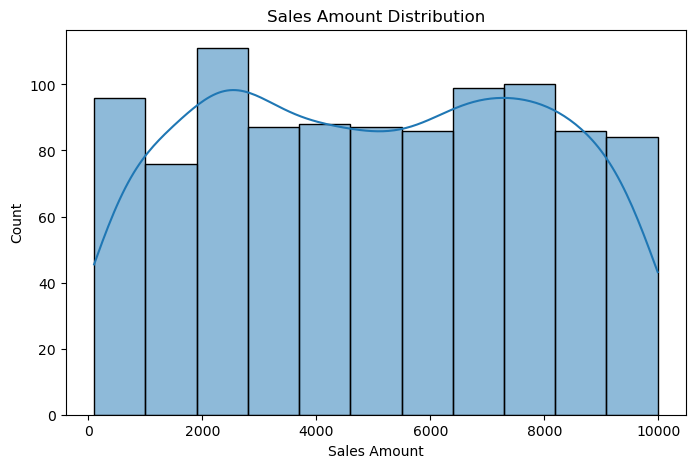

In [12]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Sales_Amount'], kde=True)
plt.title("Sales Amount Distribution")
plt.xlabel("Sales Amount")
plt.show()

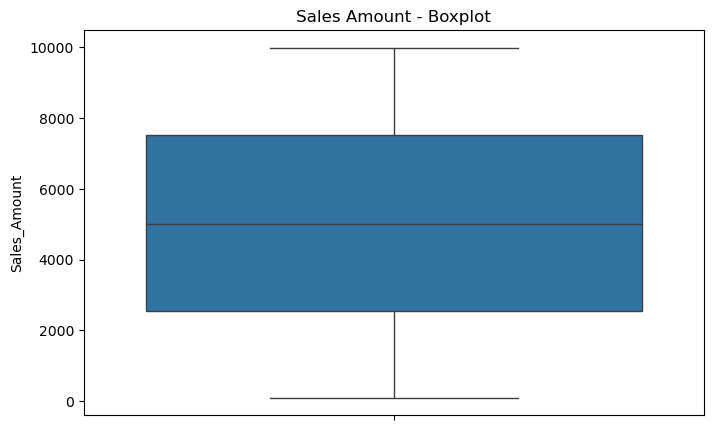

In [13]:
plt.figure(figsize=(8, 5))
sns.boxplot(y=df['Sales_Amount'])
plt.title("Sales Amount - Boxplot")
plt.show()

### Correlation Heatmap

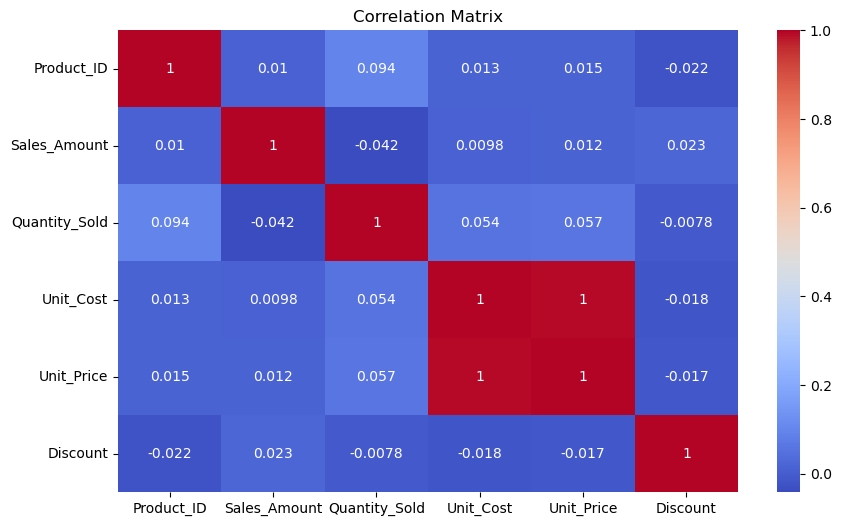

In [14]:
numeric_df = df.select_dtypes(include='number')

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

### Sales by Region

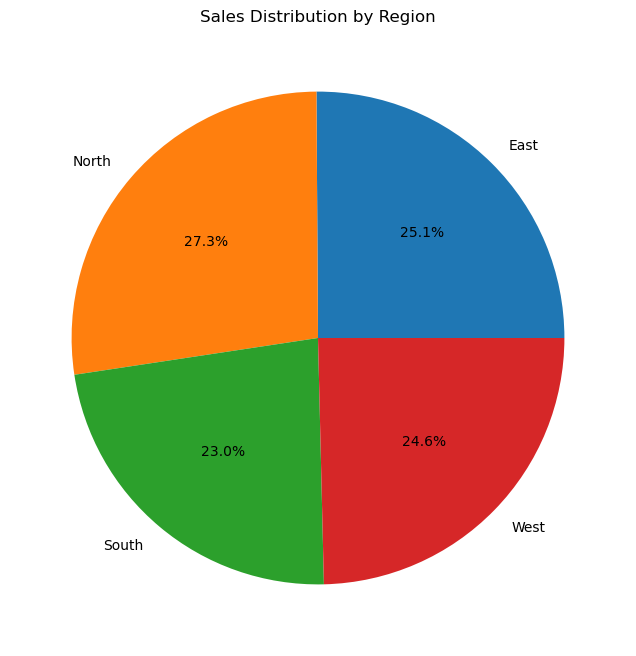

In [15]:
region_sales = df.groupby('Region')['Sales_Amount'].sum()
plt.figure(figsize=(8,8))
plt.pie(region_sales, labels=region_sales.index, autopct='%1.1f%%')
plt.title('Sales Distribution by Region')
plt.show()

### Sales by Product Category

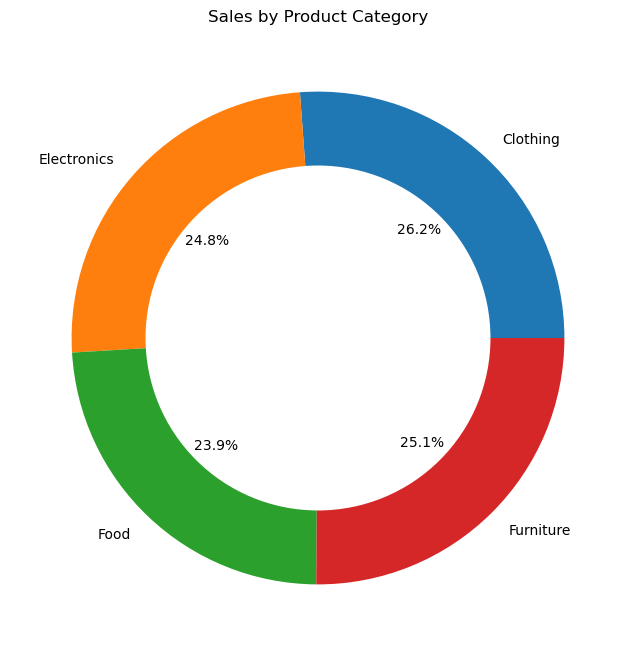

In [16]:
category_sales = df.groupby('Product_Category')['Sales_Amount'].sum()

plt.figure(figsize=(8, 8))
plt.pie(category_sales, labels=category_sales.index, autopct='%1.1f%%')

centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Sales by Product Category')
plt.show()

### Quantity Sold vs Sales Amount

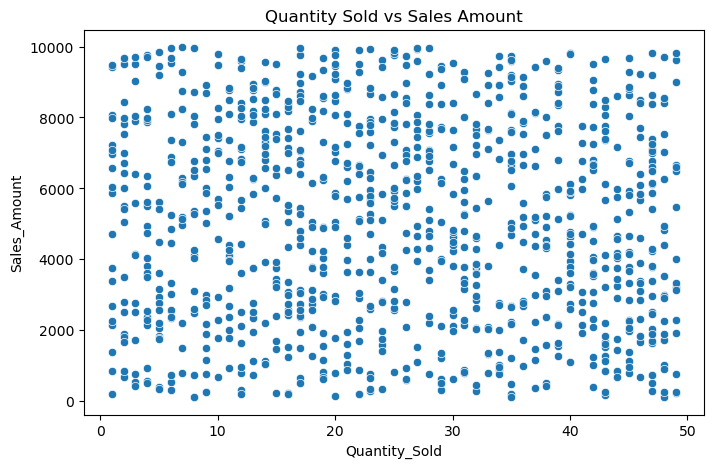

In [17]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,
                x='Quantity_Sold',
                y='Sales_Amount')

plt.title('Quantity Sold vs Sales Amount')
plt.show()

### Discount vs Sales Amount

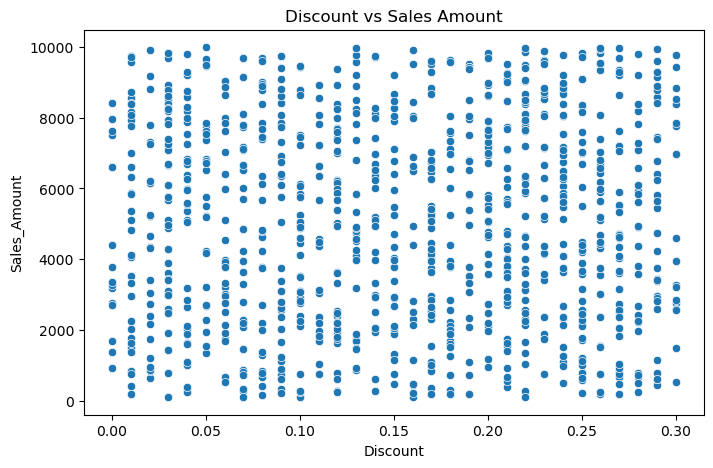

In [18]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,
                x='Discount',
                y='Sales_Amount')

plt.title('Discount vs Sales Amount')
plt.show()

###  Top 10 Sales Representatives

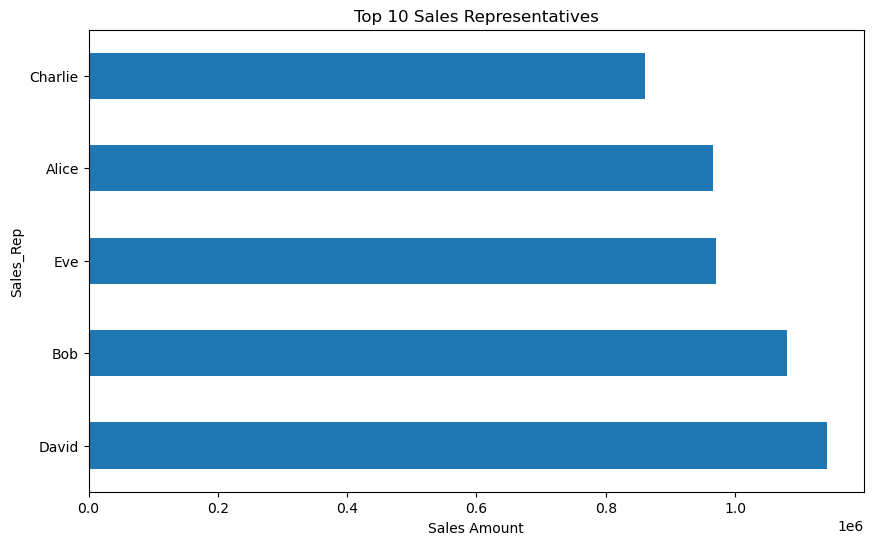

In [19]:
top_rep = df.groupby('Sales_Rep')['Sales_Amount'].sum() \
            .sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_rep.plot(kind='barh')

plt.title('Top 10 Sales Representatives')
plt.xlabel('Sales Amount')
plt.show()

### Pairplot

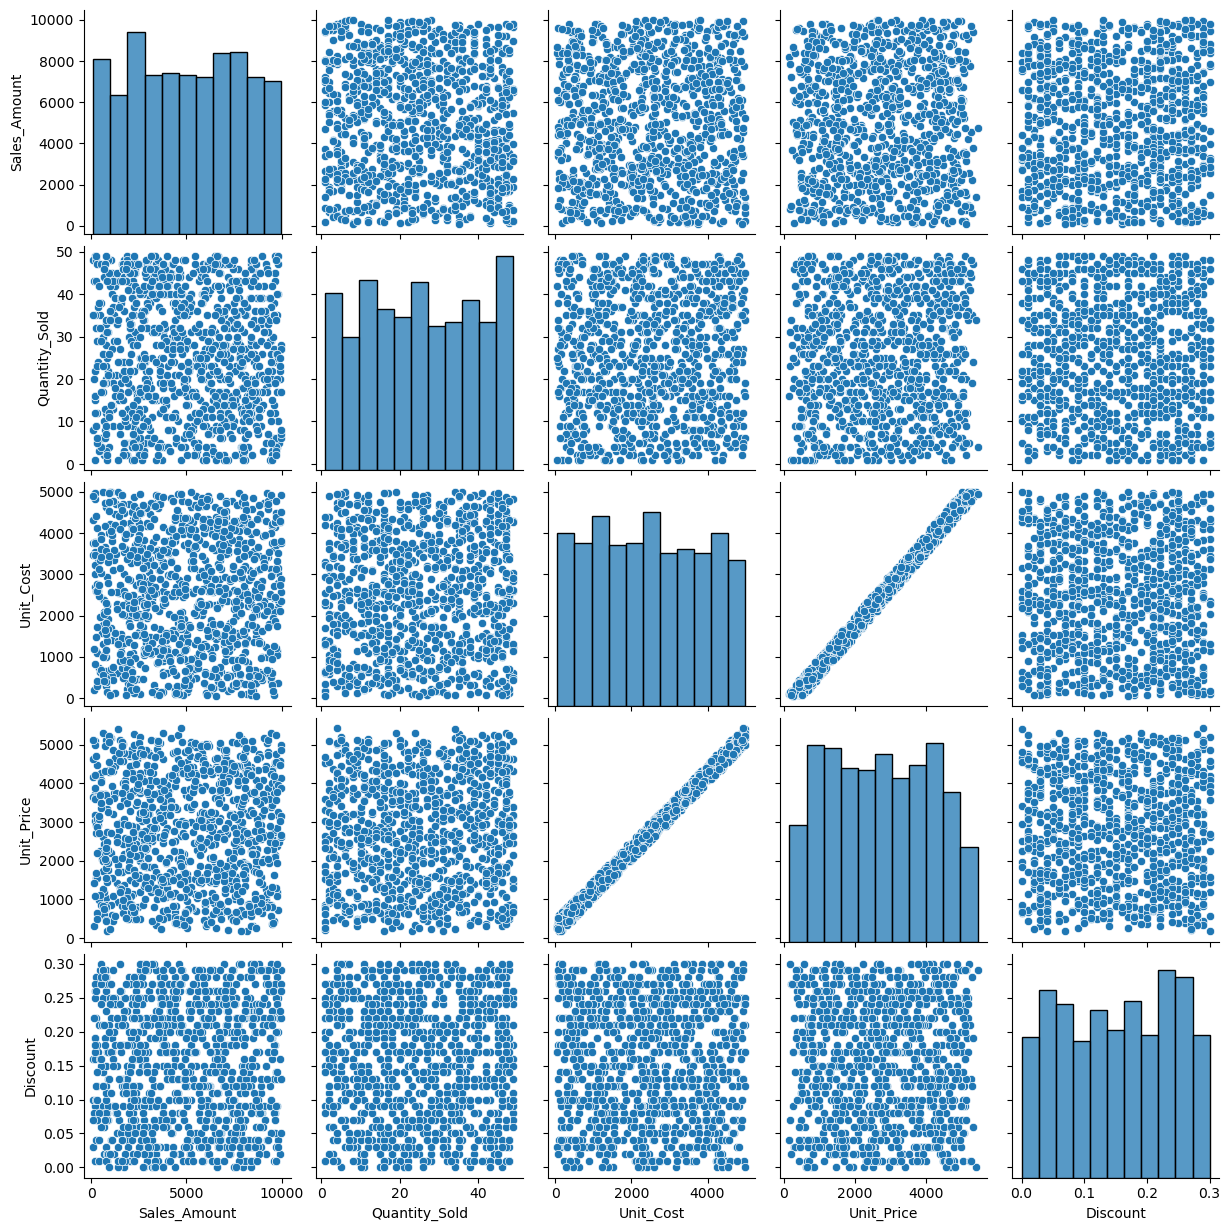

In [20]:
sns.pairplot(df[['Sales_Amount', 'Quantity_Sold', 'Unit_Cost', 'Unit_Price', 'Discount']])
plt.show()

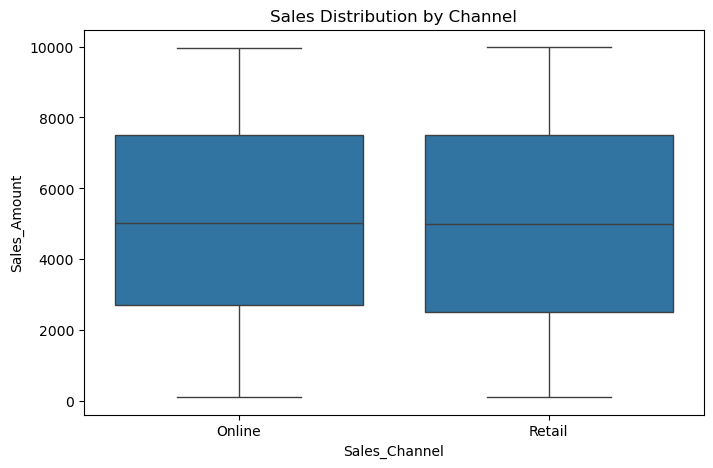

In [21]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x='Sales_Channel',
    y='Sales_Amount'
)

plt.title('Sales Distribution by Channel')
plt.show()

###  Sales by Channel and Customer Type

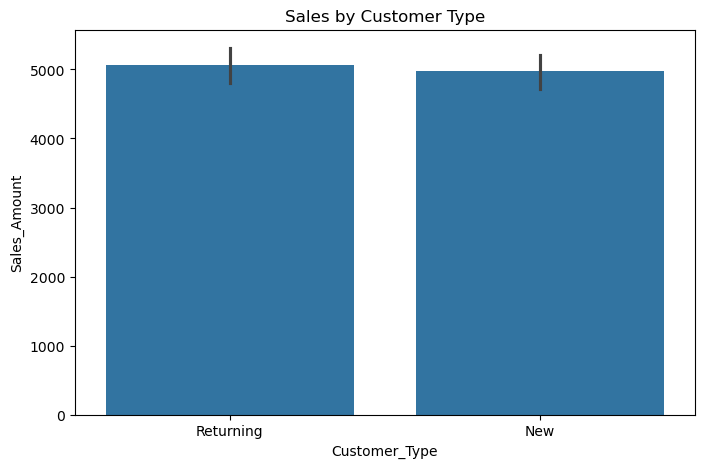

In [22]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='Customer_Type', y='Sales_Amount')
plt.title("Sales by Customer Type")
plt.show()

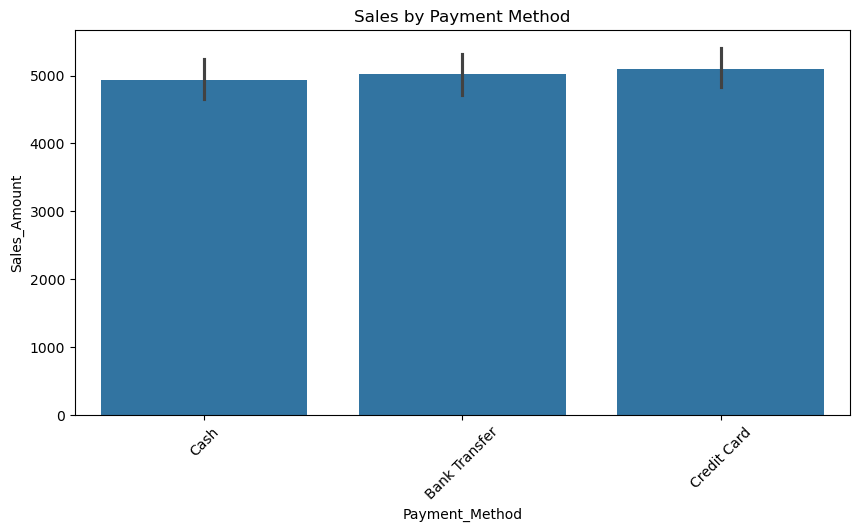

In [23]:
plt.figure(figsize=(10,5))
sns.barplot(data=df, x='Payment_Method', y='Sales_Amount')
plt.title("Sales by Payment Method")
plt.xticks(rotation=45)
plt.show()

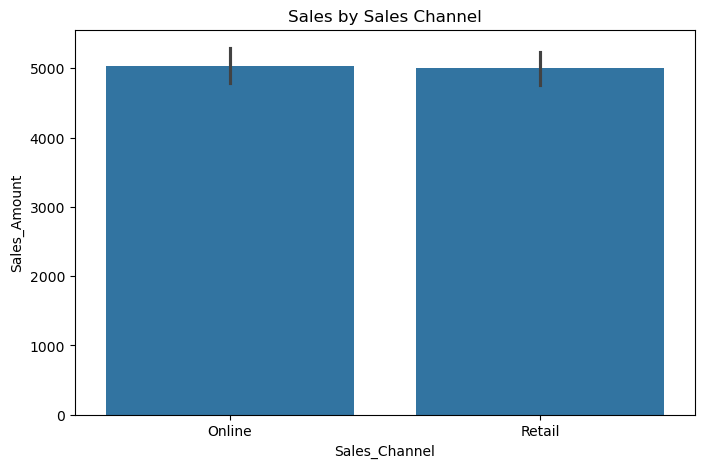

In [24]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='Sales_Channel', y='Sales_Amount')
plt.title("Sales by Sales Channel")
plt.show()

## Step 6: Key Observations

After looking at the data and charts, here are a few things I noticed:

- Sales Amount is positively correlated with Quantity Sold — more units sold means higher revenue.
- A few regions contribute the most to total sales.
- Some product categories clearly perform better than others.
- The top 10 sales reps bring in a large portion of the total revenue.
- Discounts don't always seem to lead to higher sales amounts.